<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/3450_CaseStudy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Bunderson - Case Study 1

#Question 1

#Introduction
Mercury contamination in freshwater fish is a significant environmental and public health concern, as elevated mercury levels pose risks to both humans and wildlife. To better understand factors associated with mercury accumulation in fish, data were collected from 53 lakes across Florida. For each lake, average mercury concentrations in largemouth bass muscle tissue were measured and paired with water quality characteristics, including pH. The pH values were categorized as either acidic (pH < 7) or basic (pH ≥ 7) using averages from surface water samples collected in August 1990 and March 1991. This analysis investigates whether the average mercury concentration in fish differs between lakes with acidic water and those with basic water. Identifying such a difference would provide insight into whether lake water acidity is associated with increased mercury accumulation in fish.

**Null hypothesis (H₀):** There is no difference in the distribution of mercury concentrations in fish between acidic and basic lakes.

**Alternative hypothesis (Hₐ):** There is a difference in the distribution of mercury concentrations in fish between acidic and basic lakes.

In [ ]:
df <- read.csv("/lake mercury data.csv")
attach(df)

# Print the first few rows of the DataFrame
print("Data loaded successfully into a DataFrame named 'df'.")
head(df)

The following objects are masked from df (pos = 4):

    Alkalinity, Avg_Mercury, Calcium, Calcium_cat, Chlorophyll, ID,
    Lake, Mercury_cat, pH, pH_cat




[1] "Data loaded successfully into a DataFrame named 'df'."


,ID,Lake,Alkalinity,pH,pH_cat,Calcium,Calcium_cat,Chlorophyll,Avg_Mercury,Mercury_cat
,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,1,Alligator,5.9,6.1,acid,3.0,low,0.7,1.23,unsafe
2,2,Annie,3.5,5.1,acid,1.9,low,3.2,1.33,unsafe
3,3,Apopka,116.0,9.1,base,44.1,high,128.3,0.04,acceptable
4,4,Blue Cypress,39.4,6.9,acid,16.4,medium,3.5,0.44,acceptable
5,5,Brick,2.5,4.6,acid,2.9,low,1.8,1.20,unsafe
6,6,Bryant,19.6,7.3,base,4.5,low,44.1,0.27,acceptable


#Graphical Analysis

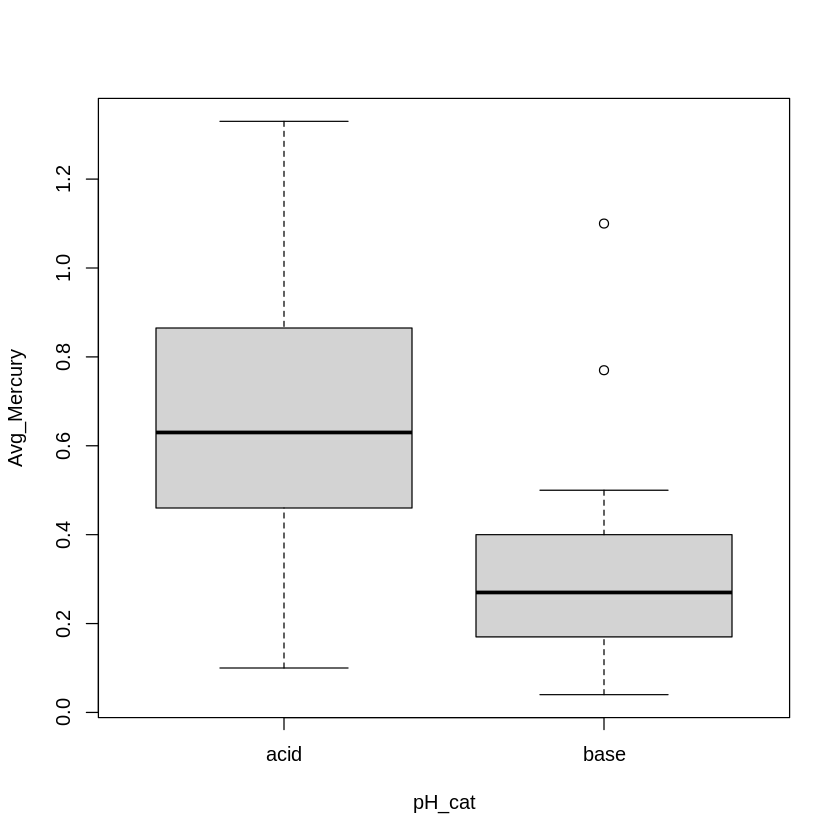

In [ ]:
boxplot(Avg_Mercury ~ pH_cat, data = df)

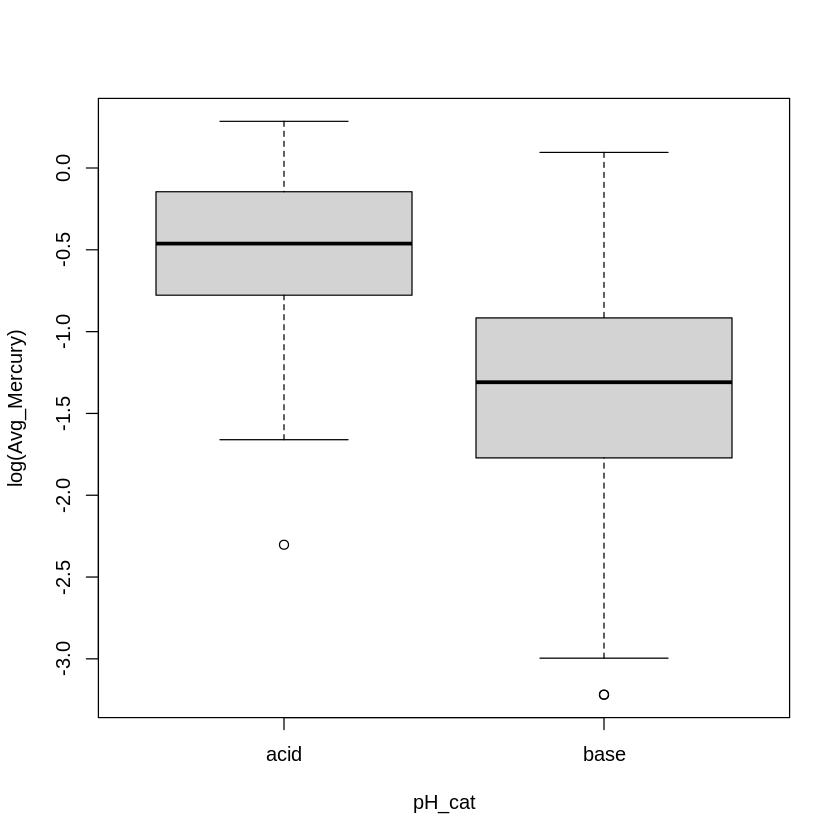

In [ ]:
boxplot(log(Avg_Mercury) ~ pH_cat, data = df)

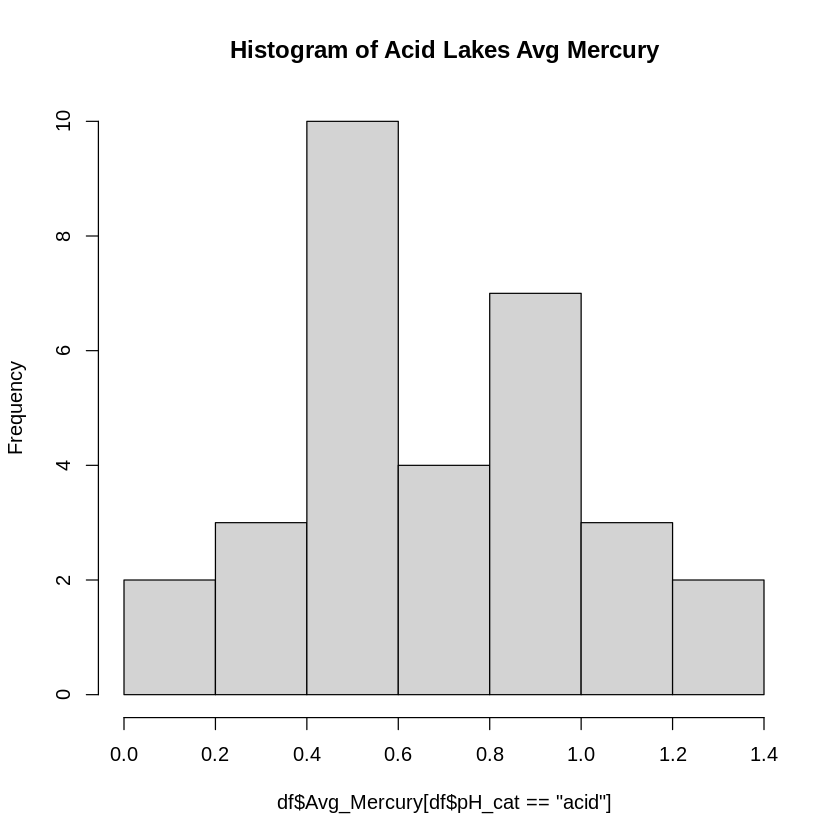

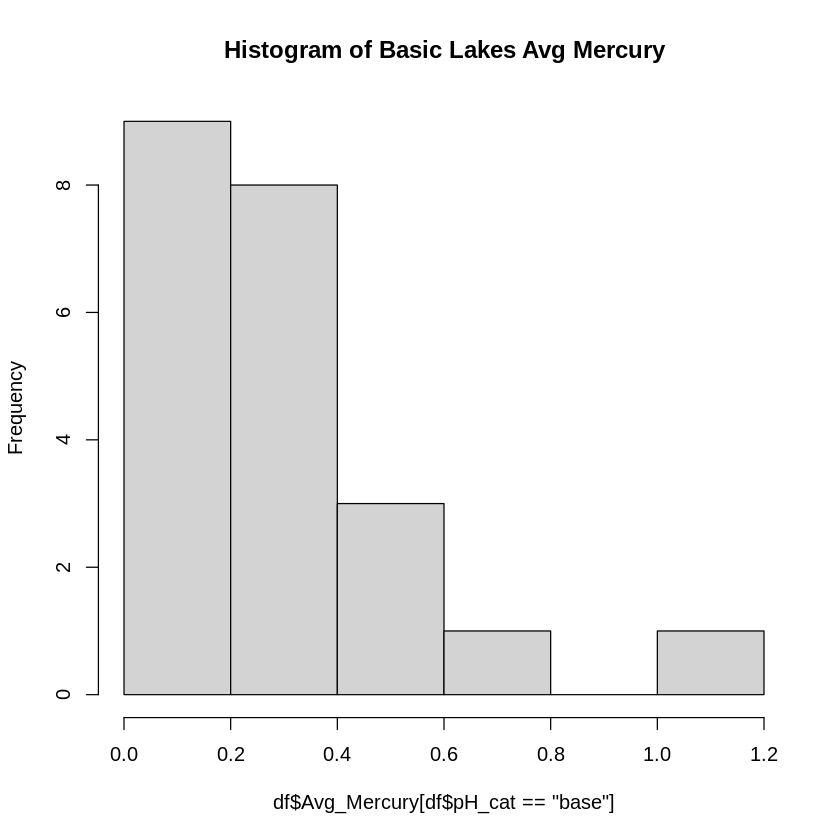

In [ ]:
hist(df$Avg_Mercury[df$pH_cat == 'acid'], main = paste("Histogram of Acid Lakes Avg Mercury"))
hist(df$Avg_Mercury[df$pH_cat == 'base'], main = paste("Histogram of Basic Lakes Avg Mercury"))

Boxplots of average mercury concentration by pH category show that lakes with acidic water tend to have higher mercury concentrations than lakes with basic water. Basic lakes average mercury levels show a right-skewed distribution, with several high-mercury outliers. This indicates that the normality assumption required for a two-sample t-test may not be reasonable.

#Assumptions for a t-test

###Independence
Although multiple fish were sampled within each lake, the mercury concentrations were averaged so that each observation represents a single lake. Since no lake appears more than once in the dataset, and lakes are distinct systems, the observations can reasonably be treated as independent.
###Normality

In [ ]:
shapiro.test(df$Avg_Mercury[df$pH_cat == 'acid'])
shapiro.test(df$Avg_Mercury[df$pH_cat == 'base'])


	Shapiro-Wilk normality test

data:  df$Avg_Mercury[df$pH_cat == "acid"]
W = 0.97451, p-value = 0.6501



	Shapiro-Wilk normality test

data:  df$Avg_Mercury[df$pH_cat == "base"]
W = 0.83349, p-value = 0.001757


In [ ]:
shapiro.test(log(df$Avg_Mercury[df$pH_cat == 'acid']))
shapiro.test(log(df$Avg_Mercury[df$pH_cat == 'base']))


	Shapiro-Wilk normality test

data:  log(df$Avg_Mercury[df$pH_cat == "acid"])
W = 0.92834, p-value = 0.03952



	Shapiro-Wilk normality test

data:  log(df$Avg_Mercury[df$pH_cat == "base"])
W = 0.92853, p-value = 0.1143


Normality was assessed using histograms, boxplots, and Shapiro–Wilk tests within each pH group. The raw mercury data were heavily right-skewed in both acidic and basic lakes. Shapiro–Wilk tests indicated departures from normality, particularly for acidic lakes. A log transformation improved symmetry for the basic lakes but did not fully normalize the acidic group. Because the normality assumption was not reasonably met for both groups, a two-sample t-test was not appropriate.

In [ ]:
table(df$pH_cat)


acid base 
  31   22 

#Homogeneity (Variances)

In [ ]:
install.packages("lawstat")
library(lawstat)

# Levene's test on raw data
print("Levene's Test on raw Avg_Mercury data:")
levene.test(df$Avg_Mercury, df$pH_cat, location="median")

# Levene's test on log-transformed data
print("Levene's Test on log-transformed Avg_Mercury data:")
levene.test(log(df$Avg_Mercury), df$pH_cat, location="median")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Levene's Test on raw Avg_Mercury data:"



	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  df$Avg_Mercury
Test Statistic = 3.3567, p-value = 0.07277


[1] "Levene's Test on log-transformed Avg_Mercury data:"



	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  log(df$Avg_Mercury)
Test Statistic = 1.9032, p-value = 0.1737


Levene’s test did not provide strong evidence of unequal variances; however, given the clear skewness and non-normality of the data, a nonparametric method was selected regardless of variance considerations.

Because the mercury data were strongly skewed and the normality assumption required for a two-sample t-test was not met, a nonparametric Wilcoxon Rank Sum Test was used to compare mercury levels between acidic and basic lakes.

In [ ]:
wilcox.test(Avg_Mercury ~ pH_cat, data = df)

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”



	Wilcoxon rank sum test with continuity correction

data:  Avg_Mercury by pH_cat
W = 571.5, p-value = 3.272e-05
alternative hypothesis: true location shift is not equal to 0


#Statistical Conclusions
A Wilcoxon Rank Sum Test was conducted to compare mercury concentrations in fish from acidic and basic lakes. The resulting p-value was very small (p < 0.001), providing compelling evidence against the null hypothesis. These results indicate that mercury concentrations in fish from acidic lakes and mercury concentrations in fish from basic lakes were different. This conclusion is consistent with the graphical analysis, which showed higher and more variable mercury levels in acidic lakes.

#Scope of Inference
This study is observational in nature, as lake acidity was not experimentally assigned. Therefore, the conclusions support an association between lake pH and mercury levels in fish, but do not establish causation. The results are most appropriately generalized to similar Florida lakes and to largemouth bass, the species sampled in this study. While the evidence of association is convincing, causal conclusions cannot be drawn.

#Question 2

#Introduction
Mercury accumulation in freshwater fish may be influenced by the chemical composition of lake water, including mineral content such as calcium. Using data from 53 lakes in Florida, this analysis examines whether calcium concentration in lake water is associated with whether mercury levels in largemouth bass exceed Florida’s safety standard of 0.5 parts per million. Calcium levels were categorized as low, medium, or high based on measured concentrations, and average mercury concentrations in fish were classified as either acceptable or unsafe. This analysis investigates whether the proportion of lakes with unsafe mercury levels differs across calcium categories, which would suggest a relationship between calcium concentration and mercury contamination in fish.

**H₀:** Calcium category and mercury acceptability are independent.

**Hₐ:** Calcium category and mercury acceptability are associated.

#Graphical Analysis

        
         acceptable    unsafe
  high    0.7857143 0.2142857
  low     0.3333333 0.6666667
  medium  0.5714286 0.4285714

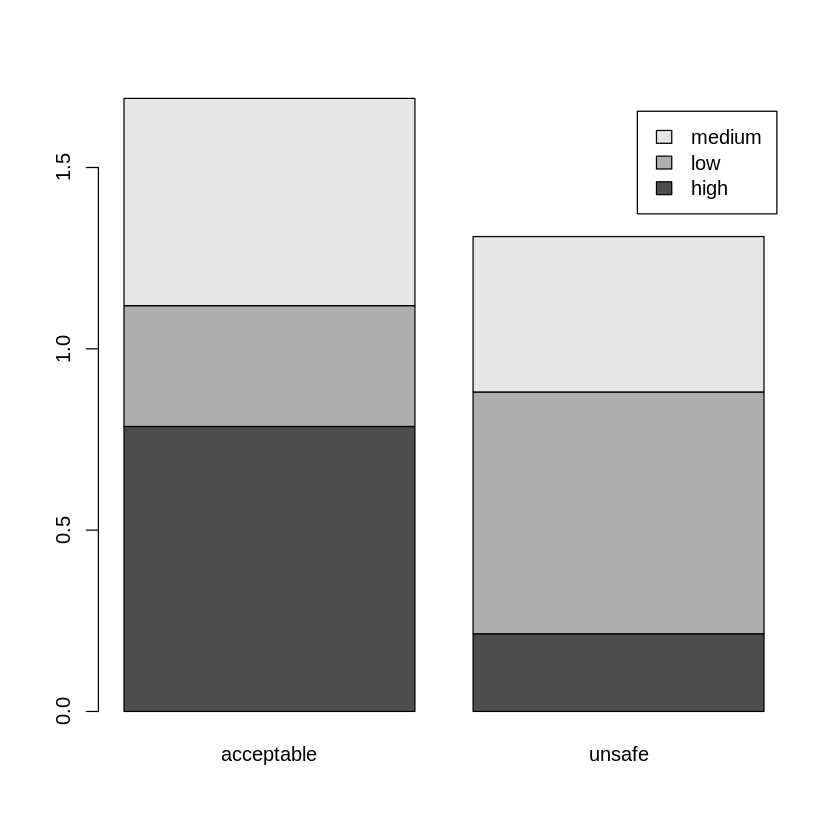

In [ ]:
prop.table(table(df$Calcium_cat, df$Mercury_cat), 1)
barplot(prop.table(table(df$Calcium_cat, df$Mercury_cat), 1),
        beside = FALSE, legend = TRUE)

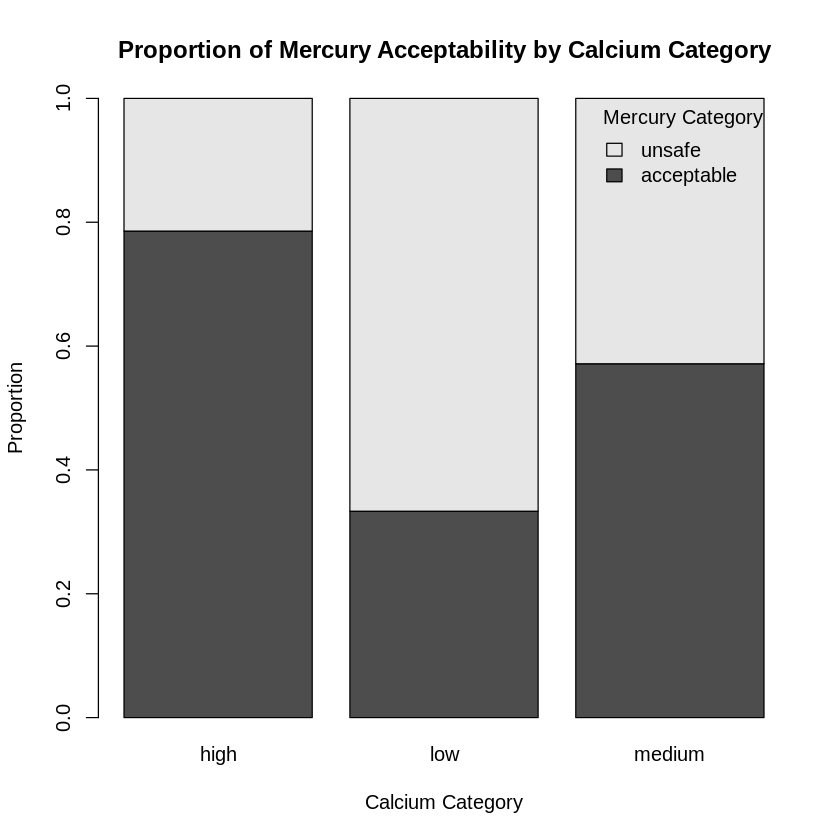

In [ ]:
# Contingency table
contingency_table <- table(df$Calcium_cat, df$Mercury_cat)

# Proportions within each Calcium category
proportions_table <- prop.table(contingency_table, margin = 1)
df$Calcium_cat <- factor(df$Calcium_cat,
                         levels = c("low", "medium", "high"))

# Segmented bar chart
barplot(t(proportions_table),
        beside = FALSE,
        main = "Proportion of Mercury Acceptability by Calcium Category",
        xlab = "Calcium Category",
        ylab = "Proportion",
        legend.text = colnames(proportions_table),
        args.legend = list(x = "topright", bty = "n", title = "Mercury Category"),
        ylim = c(0, 1))

In [ ]:
table(df$Calcium_cat, df$Mercury_cat)

        
         acceptable unsafe
  low             6     12
  medium         12      9
  high           11      3

In [ ]:
# Create the observed contingency table
observed_table <- table(df$Calcium_cat, df$Mercury_cat)

# Perform a chi-square test to get the expected counts
chi_sq_result <- chisq.test(observed_table)

# Extract and print the expected counts
print("Expected cell counts:")
print(chi_sq_result$expected)

[1] "Expected cell counts:"
        
         acceptable   unsafe
  low      9.849057 8.150943
  medium  11.490566 9.509434
  high     7.660377 6.339623


Both calcium category and mercury acceptability are categorical variables, making a chi-square test of independence appropriate for assessing whether the two variables are associated. Examination of the contingency table showed that all expected cell counts exceeded 5, satisfying the assumptions required for the chi-square test.

#Assumptions
#Independence
Each observation represents a different lake, and no lake appears more than once in the data set, so the observations can reasonably be treated as independent.

#Expected Cell Counts
All expected counts in the contingency table were greater than 5, satisfying the requirements for the chi-square test.

In [ ]:
# Perform the chi-square test of independence
chisq.test(df$Calcium_cat, df$Mercury_cat)


	Pearson's Chi-squared test

data:  df$Calcium_cat and df$Mercury_cat
X-squared = 6.5869, df = 2, p-value = 0.03713


#Statistical Conclusions
A chi-square test of independence was conducted to examine the relationship between calcium category and mercury acceptability in fish. The test produced a chi-square statistic of 6.59 with 2 degrees of freedom and a p-value of 0.037. Because the p-value is less than 0.05, we reject the null hypothesis of independence.

There is moderate evidence of an association between lake calcium concentration and whether mercury levels in fish are acceptable. Specifically, lakes with lower calcium concentrations tend to have a higher proportion of unsafe mercury levels compared to lakes with medium or high calcium concentrations.

#Scope of Inference
This study is observational, as lake calcium levels were not experimentally assigned. Therefore, the results support an association between calcium concentration and mercury acceptability in fish but do not establish causation. The conclusions are most appropriately generalized to lakes similar to those sampled in Florida and to largemouth bass, the species studied. Given the statistically significant results and clear pattern in the data, the evidence for an association is convincing; however, causal claims cannot be made.

#Question 3

#Introduction
Mercury accumulation in fish is an important environmental and public health concern, as it can be influenced by ecological factors in lakes. One factor that may affect mercury levels is chlorophyll concentration, which reflects biological productivity in a lake. Using data from 53 lakes in Florida, this analysis examines how chlorophyll levels in lake water relate to mercury concentrations in largemouth bass. Chlorophyll measurements were averaged from samples collected in August 1990 and March 1991, and mercury concentrations in fish were averaged at the lake level. Mercury is treated as the response variable, with chlorophyll as the explanatory variable.

**H₀:** The mercury levels are the same for lakes across chlorophyll levels.

**Hₐ:** The mean mercury levels differ for lakes across chlorophyll levels.

#Graphical Analysis

In [ ]:
#median chlorophyll
median_chlorolphyll = median(df$Chlorophyll)
print("Median Chlorophyll concentration:")
print(median_chlorolphyll)

#mean mercury level
mean_mercury = mean(df$Avg_Mercury)
print("Mean mercury concentration: ")
print(mean_mercury)

[1] "Median Chlorophyll concentration:"
[1] 12.8
[1] "Mean mercury concentration: "
[1] 0.5271698


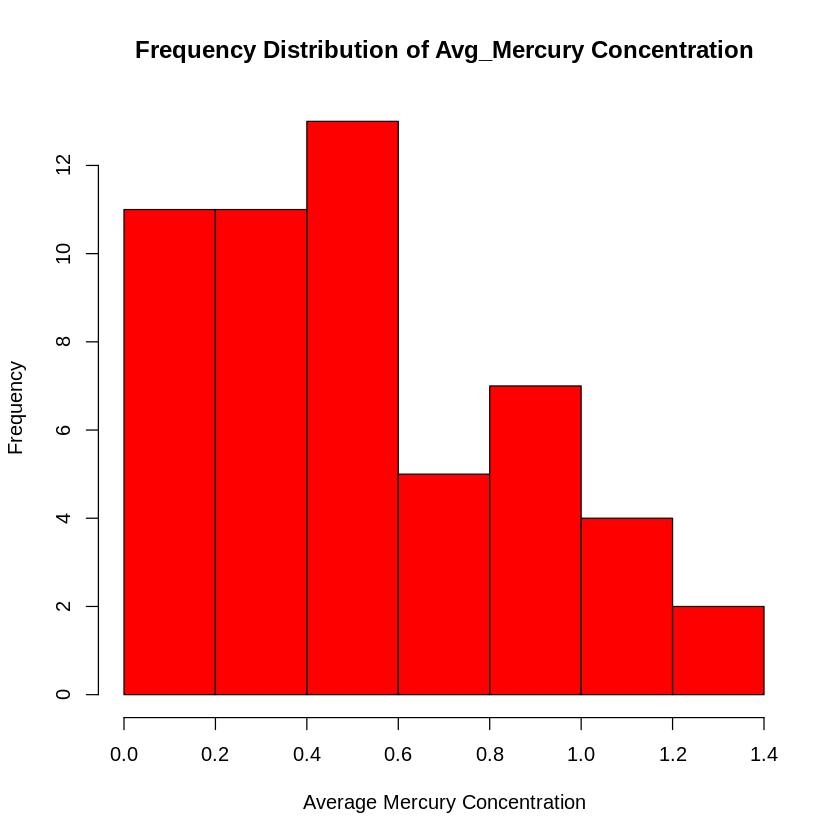

In [ ]:
hist(df$Avg_Mercury,
     main = "Frequency Distribution of Avg_Mercury Concentration",
     xlab = "Average Mercury Concentration",
     ylab = "Frequency",
     col = "red",
     border = "black")

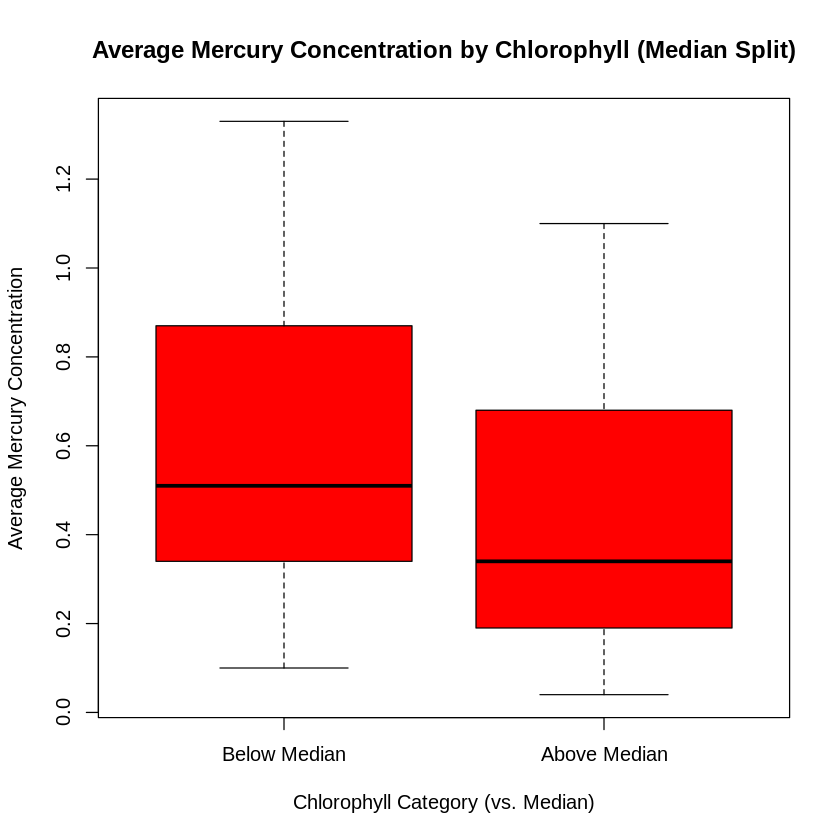

In [ ]:
# Calculate the median chlorophyll again (it was already calculated but for clarity)
median_chlorophyll_val = median(df$Chlorophyll, na.rm = TRUE)

# Create a new categorical variable for above/below median chlorophyll
df$Chlorophyll_median_cat <- ifelse(df$Chlorophyll >= median_chlorophyll_val, "Above Median", "Below Median")

# Ensure the new category is a factor for proper plotting
df$Chlorophyll_median_cat <- factor(df$Chlorophyll_median_cat, levels = c("Below Median", "Above Median"))

# Generate a box plot of average mercury concentration by above/below median chlorophyll category
boxplot(Avg_Mercury ~ Chlorophyll_median_cat, data = df,
        main = "Average Mercury Concentration by Chlorophyll (Median Split)",
        xlab = "Chlorophyll Category (vs. Median)",
        ylab = "Average Mercury Concentration",
        col = "red")

The median chlorophyll concentration was calculated to divide lakes into two groups: below-median and above-median chlorophyll levels. This categorization allows comparison of mercury levels between lakes with relatively low and high biological productivity.


A histogram of average mercury concentrations (above) shows the distribution of mercury across lakes. A boxplot comparing mercury concentrations between chlorophyll categories suggests that lakes with higher chlorophyll levels tend to have higher mercury concentrations.

#Assumptions
It seems like we could do a t-test, but let's check the assumptions!

#Independence
Each observation represents a different lake, and measurements were averaged at the lake level. Since no lake appears more than once, independence is reasonable.

#Normality

In [ ]:
shapiro.test(df$Avg_Mercury[df$Chlorophyll_median_cat == 'Below Median'])
shapiro.test(df$Avg_Mercury[df$Chlorophyll_median_cat == 'Above Median'])


	Shapiro-Wilk normality test

data:  df$Avg_Mercury[df$Chlorophyll_median_cat == "Below Median"]
W = 0.92691, p-value = 0.06542



	Shapiro-Wilk normality test

data:  df$Avg_Mercury[df$Chlorophyll_median_cat == "Above Median"]
W = 0.93015, p-value = 0.06969


These are not wonderful... let's test the log transformed data

In [ ]:
shapiro.test(log(df$Avg_Mercury[df$Chlorophyll_median_cat == 'Below Median']))
shapiro.test(log(df$Avg_Mercury[df$Chlorophyll_median_cat == 'Above Median']))


	Shapiro-Wilk normality test

data:  log(df$Avg_Mercury[df$Chlorophyll_median_cat == "Below Median"])
W = 0.95312, p-value = 0.2741



	Shapiro-Wilk normality test

data:  log(df$Avg_Mercury[df$Chlorophyll_median_cat == "Above Median"])
W = 0.91216, p-value = 0.02565


The log transformed data did not help. We will stick with the original.

Shapiro–Wilk tests were conducted within each chlorophyll category. The results do not provide strong evidence **against** normality. Additionally, the two-sample t-test is fairly robust to moderate departures from normality, especially with similar group sizes.

#Equality of Variance

In [ ]:
print("Levene's Test on Avg_Mercury data by Chlorophyll Median Category:")
levene.test(df$Avg_Mercury, df$Chlorophyll_median_cat, location="median")

[1] "Levene's Test on Avg_Mercury data by Chlorophyll Median Category:"



	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  df$Avg_Mercury
Test Statistic = 0.22974, p-value = 0.6338


Levene’s test yielded a p-value of 0.6338, so we fail to reject the null hypothesis of equal variances. Therefore, the equal-variance t-test is appropriate.

In [ ]:
t.test(Avg_Mercury ~ Chlorophyll_median_cat, data = df, var.equal = TRUE)


	Two Sample t-test

data:  Avg_Mercury by Chlorophyll_median_cat
t = 2.135, df = 51, p-value = 0.03759
alternative hypothesis: true difference in means between group Below Median and group Above Median is not equal to 0
95 percent confidence interval:
 0.01154717 0.37554685
sample estimates:
mean in group Below Median mean in group Above Median 
                 0.6257692                  0.4322222 


#Statistical Conclusions
A two-sample t-test comparing mean mercury levels between lakes above and below the median chlorophyll concentration produced:

*   p-value = 0.0376
*   95% confidence interval for the difference in means: (0.0115, 0.3755)

Because the p-value is less than 0.05, we reject the null hypothesis.

There is statistically significant evidence that mean mercury levels differ between lakes with high versus low chlorophyll concentrations. However, this result is solely suggestive, rather than convincing evidence.

#Scope of Inference
Because the chlorophyll concentrations and mercury categories were observed rather than randomly assigned, this study is observational. As a result, we cannot make causal conclusions about the effect of chlorophyll on mercury levels in fish. The results may be generalized only to fish from similar lakes and environmental conditions represented in this dataset, and only if the fish can reasonably be considered a representative sample. No cause-and-effect relationship can be inferred.

#Question 4

#Overall Conclusions
Across all analyses, there is compelling evidence that water chemistry is associated with mercury accumulation in fish. Lakes with acidic water tended to have higher mercury concentrations, lakes with low calcium concentrations were more likely to exceed safety thresholds, and mercury levels differed significantly between levels of chlorophyll that were above the median value of chlorophyll and levels of chlorophyll that were below the median value. While these results are based on observational data and do not imply causation, they highlight meaningful associations that warrant further investigation using more advanced methods.

In [ ]:
detach(df)